In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import kruskal

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.api import VAR
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.stattools import acf

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
PROC = Path(r"D:\yield_curve_forecast\data\processed")

maturities = np.array([0.25, 1, 2, 5, 10, 30])
yield_col = ["DGS3MO", "DGS1", "DGS2", "DGS5", "DGS10", "DGS30"]
Y_full = pd.read_parquet(PROC / "yield_curve_data.parquet").set_index("observation_date")[yield_col]
Y_full = Y_full.dropna()

exog_cols = ["FEDFUNDS", "INFLATION_YOY", "UNRATE", "VIX_LOG"]
feat = pd.read_parquet(PROC / "features.parquet")
if "observation_date" in feat.columns:
    feat = feat.set_index("observation_date")
EXOG_full = feat[exog_cols].reindex(Y_full.index)   

exog_valid_start = EXOG_full.dropna().index.min()
common_start = max(Y_full.index.min(), exog_valid_start)

Y = Y_full.loc[common_start:]
EXOG = EXOG_full.loc[common_start:]

assert EXOG.isna().sum().sum() == 0, "EXOG still has NaNs after trimming: investigate before proceeding"

TEST_SIZE = 60
split = len(Y) - TEST_SIZE
train_init = Y.iloc[:split]
test_dates = Y.index[split:]

print(f"Raw panel starts   : {Y_full.index[0].date()}")
print(f"EXOG valid from    : {exog_valid_start.date()}  (burn-in from lagged/YoY macro features)")
print(f"Modeling window    : {Y.index[0].date()} -> {Y.index[-1].date()}  ({len(Y)} months)")
print(f"Initial train      : {train_init.index[0].date()} -> {train_init.index[-1].date()}  ({len(train_init)})")
print(f"Test (OOS)         : {test_dates[0].date()} -> {test_dates[-1].date()}  ({TEST_SIZE})")

Raw panel starts   : 1992-01-01
EXOG valid from    : 1994-02-01  (burn-in from lagged/YoY macro features)
Modeling window    : 1994-02-01 -> 2025-09-01  (380 months)
Initial train      : 1994-02-01 -> 2020-09-01  (320)
Test (OOS)         : 2020-10-01 -> 2025-09-01  (60)


In [3]:
def best_arima_order(series, exog=None, p_range=(0, 1, 2), q_range=(0, 1, 2)):
    best_aic, best_order = np.inf, (0, 1, 0)
    for p in p_range:
        for q in q_range:
            try:
                aic = SARIMAX(series, exog=exog, order=(p, 1, q),
                               enforce_stationarity=False, enforce_invertibility=False
                               ).fit(disp=False).aic
                if aic < best_aic:
                    best_aic, best_order = aic, (p, 1, q)
            except Exception:
                continue
    return best_order

#ARIMA orders (no exog)
arima_orders = {c: best_arima_order(train_init[c]) for c in yield_col}

#ARIMAX orders (same grid, with exog)
arimax_orders = {c: best_arima_order(train_init[c], exog=EXOG.loc[train_init.index]) for c in yield_col}

print("ARIMA orders (identified on train):")
for c, o in arima_orders.items():
    print(f"  {c}: ARIMA{o}")

print("\nARIMAX orders (identified on train, with exog):")
for c, o in arimax_orders.items():
    print(f"  {c}: ARIMAX{o}")

#VAR lag (on differenced train)
var_lag = max(VAR(train_init.diff().dropna()).select_order(maxlags=6).aic, 1)
print(f"\nVAR(diff) lag  : {var_lag}")

ARIMA orders (identified on train):
  DGS3MO: ARIMA(1, 1, 1)
  DGS1: ARIMA(2, 1, 0)
  DGS2: ARIMA(1, 1, 1)
  DGS5: ARIMA(1, 1, 1)
  DGS10: ARIMA(1, 1, 2)
  DGS30: ARIMA(2, 1, 1)

ARIMAX orders (identified on train, with exog):
  DGS3MO: ARIMAX(2, 1, 2)
  DGS1: ARIMAX(2, 1, 0)
  DGS2: ARIMAX(0, 1, 1)
  DGS5: ARIMAX(1, 1, 1)
  DGS10: ARIMAX(2, 1, 1)
  DGS30: ARIMAX(2, 1, 1)

VAR(diff) lag  : 2


In [4]:
#ARIMA / ARIMAX in-sample residual diagnostics
rows = []
for c in yield_col:
    fit_a = SARIMAX(train_init[c], order=arima_orders[c],
                     enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    fit_x = SARIMAX(train_init[c], exog=EXOG.loc[train_init.index], order=arimax_orders[c],
                     enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    for label, fit in [("ARIMA", fit_a), ("ARIMAX", fit_x)]:
        resid = fit.resid.dropna()
        lb_p = acorr_ljungbox(resid, lags=[12], return_df=True)["lb_pvalue"].iloc[0]
        arch_p = het_arch(resid)[1]
        rows.append({"model": label, "maturity": c,
                     "LjungBox_p": lb_p, "resid_autocorr_free": lb_p > 0.05,
                     "ARCH_p": arch_p, "vol_clustering": arch_p < 0.05})

insample_diag = pd.DataFrame(rows)
print("In-sample residual diagnostics (ARIMA / ARIMAX, fit once on train_init):\n")
print(insample_diag.to_string(index=False))

#VAR stability check
var_fit = VAR(train_init.diff().dropna()).fit(var_lag)
print(f"\nVAR({var_lag}) stable: {var_fit.is_stable()}")

In-sample residual diagnostics (ARIMA / ARIMAX, fit once on train_init):

 model maturity  LjungBox_p  resid_autocorr_free  ARCH_p  vol_clustering
 ARIMA   DGS3MO      0.0050                False  0.0000            True
ARIMAX   DGS3MO      0.0000                False  0.0000            True
 ARIMA     DGS1      0.3948                 True  0.0017            True
ARIMAX     DGS1      0.3317                 True  0.0023            True
 ARIMA     DGS2      0.6767                 True  0.0014            True
ARIMAX     DGS2      0.4949                 True  0.0013            True
 ARIMA     DGS5      0.0212                False  0.2417           False
ARIMAX     DGS5      0.0142                False  0.2612           False
 ARIMA    DGS10      0.2093                 True  0.8089           False
ARIMAX    DGS10      0.0140                False  0.5766           False
 ARIMA    DGS30      0.0129                False  0.0008            True
ARIMAX    DGS30      0.0109                False  

In [5]:
models = ["RandomWalk", "ARIMA", "ARIMAX", "VAR_diff"]
preds = {m: pd.DataFrame(index=test_dates, columns=yield_col, dtype=float) for m in models}

for t in range(split, len(Y)):
    hist = Y.iloc[:t]                   
    hist_exog = EXOG.iloc[:t]
    fcast_exog = EXOG.iloc[t:t + 1]      
    date = Y.index[t]
    last_level = hist.iloc[-1]

    # 1) Random walk
    preds["RandomWalk"].loc[date] = last_level.values

    # 2) ARIMA per maturity
    for c in yield_col:
        try:
            f = ARIMA(hist[c], order=arima_orders[c]).fit().forecast(1).iloc[0]
        except Exception:
            f = last_level[c]
        preds["ARIMA"].loc[date, c] = f

    # 3) ARIMAX per maturity
    for c in yield_col:
        try:
            fit = SARIMAX(hist[c], exog=hist_exog, order=arimax_orders[c],
                           enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
            f = fit.forecast(1, exog=fcast_exog).iloc[0]
        except Exception:
            f = last_level[c]
        preds["ARIMAX"].loc[date, c] = f

    # 4) VAR in differences -> level
    try:
        dh = hist.diff().dropna()
        vr = VAR(dh).fit(var_lag)
        dfc = vr.forecast(dh.values[-var_lag:], steps=1)[0]
        preds["VAR_diff"].loc[date] = last_level.values + dfc
    except Exception:
        preds["VAR_diff"].loc[date] = last_level.values

actual = Y.loc[test_dates]
print("Walk-forward complete. Forecast frames built for:", models)

Walk-forward complete. Forecast frames built for: ['RandomWalk', 'ARIMA', 'ARIMAX', 'VAR_diff']


RMSE (lower = better)

         RandomWalk  ARIMA  ARIMAX  VAR_diff
DGS3MO       0.2288 0.1730  0.1993    0.2061
DGS1         0.2570 0.2282  0.2290    0.2400
DGS2         0.3068 0.3030  0.3092    0.3026
DGS5         0.3080 0.3170  0.3270    0.3144
DGS10        0.2805 0.2901  0.3044    0.2877
DGS30        0.2486 0.2539  0.2654    0.2546
AVERAGE      0.2716 0.2609  0.2724    0.2675

MAE (lower = better)

         RandomWalk  ARIMA  ARIMAX  VAR_diff
DGS3MO       0.1323 0.1110  0.1323    0.1337
DGS1         0.1793 0.1691  0.1723    0.1811
DGS2         0.2222 0.2256  0.2356    0.2301
DGS5         0.2460 0.2548  0.2620    0.2500
DGS10        0.2275 0.2370  0.2499    0.2348
DGS30        0.2042 0.2087  0.2190    0.2102
AVERAGE      0.2019 0.2010  0.2119    0.2066


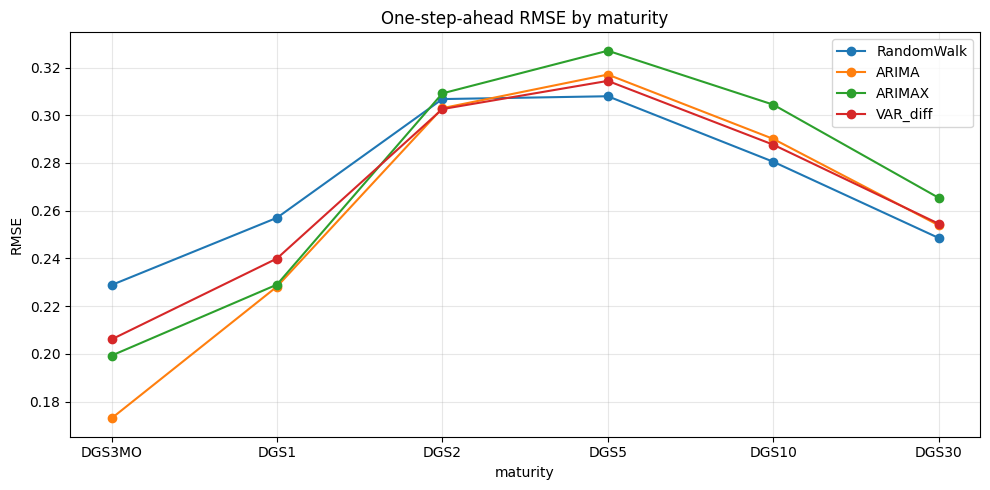

In [6]:
def rmse(a, f): return np.sqrt(np.nanmean((a - f) ** 2))
def mae(a, f):  return np.nanmean(np.abs(a - f))

rmse_tbl = pd.DataFrame({m: [rmse(actual[c], preds[m][c]) for c in yield_col] for m in models}, index=yield_col)
mae_tbl  = pd.DataFrame({m: [mae(actual[c],  preds[m][c]) for c in yield_col] for m in models}, index=yield_col)
rmse_tbl.loc["AVERAGE"] = rmse_tbl.mean()
mae_tbl.loc["AVERAGE"]  = mae_tbl.mean()

print("RMSE (lower = better)\n")
print(rmse_tbl)
print("\nMAE (lower = better)\n")
print(mae_tbl)

ax = rmse_tbl.drop("AVERAGE").plot(marker="o", figsize=(10, 5))
ax.set_title("One-step-ahead RMSE by maturity")
ax.set_xlabel("maturity"); ax.set_ylabel("RMSE"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [7]:
#Persist forecasts + actuals so 05_dns.ipynb can compare against them
save_preds = pd.concat({m: preds[m] for m in models}, axis=1)
save_preds.columns = [f"{m}__{c}" for m, c in save_preds.columns]
save_preds.to_parquet(PROC / "predictions.parquet")
actual.to_parquet(PROC / "actual.parquet")
print("Saved:", PROC / "predictions.parquet")

Saved: D:\yield_curve_forecast\data\processed\predictions.parquet


In [8]:
def diebold_mariano(e1, e2, h=1, loss="MSE"):
    e1, e2 = np.asarray(e1, float), np.asarray(e2, float)
    d = (e1**2 - e2**2) if loss == "MSE" else (np.abs(e1) - np.abs(e2))
    d = d[~np.isnan(d)]
    T = len(d); dbar = d.mean()
    var = np.sum((d - dbar)**2) / T
    for k in range(1, h):
        var += 2 * np.sum((d[k:] - dbar) * (d[:-k] - dbar)) / T
    dm = dbar / np.sqrt(var / T)
    hln = np.sqrt((T + 1 - 2*h + h*(h-1)/T) / T)
    dm *= hln
    return dm, 2 * stats.t.cdf(-abs(dm), df=T-1)

comparisons = [("ARIMA", "RandomWalk", "does modeling beat naive?"),
               ("ARIMAX", "ARIMA", "does macro exogenous info help?"),
               ("VAR_diff", "ARIMA", "does multivariate help?")]

rows = []
for A, B, question in comparisons:
    for c in yield_col:
        eA = (actual[c] - preds[A][c]).values
        eB = (actual[c] - preds[B][c]).values
        dm, p = diebold_mariano(eA, eB)
        winner = A if dm < 0 else B
        rows.append({"comparison": f"{A} vs {B}", "question": question,
                     "maturity": c, "DM": dm, "p_value": p,
                     "better": winner, "significant_5%": p < 0.05})

dm_tbl = pd.DataFrame(rows)
for A, B, q in comparisons:
    sub = dm_tbl[dm_tbl["comparison"] == f"{A} vs {B}"]
    print(f"\n    {A} vs {B}  ({q})    ")
    print(sub[["maturity", "DM", "p_value", "better", "significant_5%"]].to_string(index=False))


    ARIMA vs RandomWalk  (does modeling beat naive?)    
maturity      DM  p_value     better  significant_5%
  DGS3MO -2.2619   0.0274      ARIMA            True
    DGS1 -1.7126   0.0920      ARIMA           False
    DGS2 -0.3195   0.7505      ARIMA           False
    DGS5  0.9632   0.3394 RandomWalk           False
   DGS10  1.0030   0.3199 RandomWalk           False
   DGS30  0.9178   0.3625 RandomWalk           False

    ARIMAX vs ARIMA  (does macro exogenous info help?)    
maturity     DM  p_value better  significant_5%
  DGS3MO 1.9054   0.0616  ARIMA           False
    DGS1 0.2490   0.8042  ARIMA           False
    DGS2 0.9152   0.3638  ARIMA           False
    DGS5 1.4794   0.1444  ARIMA           False
   DGS10 2.3797   0.0206  ARIMA            True
   DGS30 2.3366   0.0229  ARIMA            True

    VAR_diff vs ARIMA  (does multivariate help?)    
maturity      DM  p_value   better  significant_5%
  DGS3MO  1.6151   0.1116    ARIMA           False
    DGS1  1.3002   

In [9]:
from statsmodels.stats.multitest import multipletests

def add_multiple_testing_correction(dm_df, p_col="p_value", method="fdr_bh"):
    dm_df = dm_df.copy()
    reject, p_adj, _, _ = multipletests(dm_df[p_col], alpha=0.05, method=method)
    dm_df["p_adj"] = p_adj
    dm_df["significant_adj_5%"] = reject
    return dm_df

dm_tbl_adj = add_multiple_testing_correction(dm_tbl)
print(dm_tbl_adj[["comparison","maturity","p_value","p_adj","significant_5%","significant_adj_5%"]]
      .to_string(index=False))

         comparison maturity  p_value  p_adj  significant_5%  significant_adj_5%
ARIMA vs RandomWalk   DGS3MO   0.0274 0.1644            True               False
ARIMA vs RandomWalk     DGS1   0.0920 0.3313           False               False
ARIMA vs RandomWalk     DGS2   0.7505 0.9048           False               False
ARIMA vs RandomWalk     DGS5   0.3394 0.5457           False               False
ARIMA vs RandomWalk    DGS10   0.3199 0.5457           False               False
ARIMA vs RandomWalk    DGS30   0.3625 0.5457           False               False
    ARIMAX vs ARIMA   DGS3MO   0.0616 0.2772           False               False
    ARIMAX vs ARIMA     DGS1   0.8042 0.9048           False               False
    ARIMAX vs ARIMA     DGS2   0.3638 0.5457           False               False
    ARIMAX vs ARIMA     DGS5   0.1444 0.3712           False               False
    ARIMAX vs ARIMA    DGS10   0.0206 0.1644            True               False
    ARIMAX vs ARIMA    DGS30

In [10]:
rows = []
for m in models:
    for c in yield_col:
        err = (actual[c] - preds[m][c]).dropna()
        lb_p = acorr_ljungbox(err, lags=[12], return_df=True)["lb_pvalue"].iloc[0]
        arch_p = het_arch(err)[1]
        rows.append({"model": m, "maturity": c,
                     "LjungBox_p": lb_p, "resid_autocorr_free": lb_p > 0.05,
                     "ARCH_p": arch_p, "vol_clustering": arch_p < 0.05})

oos_diag = pd.DataFrame(rows)
for m in models:
    print(f"\n    {m}: out-of-sample forecast-error diagnostics    ")
    print(oos_diag[oos_diag.model == m][["maturity", "LjungBox_p", "resid_autocorr_free",
                                          "ARCH_p", "vol_clustering"]].to_string(index=False))


    RandomWalk: out-of-sample forecast-error diagnostics    
maturity  LjungBox_p  resid_autocorr_free  ARCH_p  vol_clustering
  DGS3MO      0.0000                False  0.0909           False
    DGS1      0.0000                False  0.2556           False
    DGS2      0.2568                 True  0.2017           False
    DGS5      0.6098                 True  0.2566           False
   DGS10      0.5283                 True  0.7219           False
   DGS30      0.5406                 True  0.6863           False

    ARIMA: out-of-sample forecast-error diagnostics    
maturity  LjungBox_p  resid_autocorr_free  ARCH_p  vol_clustering
  DGS3MO      0.0238                False  0.5628           False
    DGS1      0.6945                 True  0.3236           False
    DGS2      0.5224                 True  0.7186           False
    DGS5      0.2294                 True  0.4740           False
   DGS10      0.2835                 True  0.6010           False
   DGS30      0.6892   